In [14]:
# Import basic libraries for data handling
import pandas as pd
import numpy as np

# Import feature selection tool from sklearn
from sklearn.feature_selection import SelectKBest, f_regression

In [16]:
# Load the cleaned market dataset
df = pd.read_csv(r"D:\Downloads\final_clean_market_dataset1.csv")

# Display first 5 rows of the dataset
print(df.head())

# Display information about columns and data types
print(df.info())

   OBJECTID  PropertyID  xrCompositeLandUseID  xrBuildingTypeID     ParcelID  \
0         1           8                     3               6.0  121-698-063   
1         2           9                     3               3.0  121-698-062   
2         3          12                     3               6.0  144-698-066   
3         5          25                     3               6.0  144-698-053   
4         7          29                     3               3.0  144-698-049   

   LocationStartNumber StreetNameAndWay  xrPrimaryNeighborhoodID  LandSF  \
0                   77      STAFFORD ST                        2  6000.0   
1                   73      STAFFORD ST                        2  6000.0   
2                   61      STAFFORD ST                        2  6000.0   
3                  211    NEWINGTON AVE                        2  5040.0   
4                   18       BRISTOL ST                        2  6000.0   

   TotalFinishedArea  ...       PrimaryGrantor                

In [21]:
# Convert SaleDate column to datetime format
# Converting to datetime allows us to extract year and month information.
df['SaleDate'] = pd.to_datetime(df['SaleDate'])

In [22]:
# Extract the year from the sale date
# Property prices may change across different years.
df['SaleYear'] = df['SaleDate'].dt.year

In [23]:
# Extract the month from the sale date
# Some months may have more property sales than others.
df['SaleMonth'] = df['SaleDate'].dt.month

In [24]:
# Calculate price per square foot
# This helps measure property price efficiency.
df['PricePerSF'] = df['SalePrice'] / df['TotalFinishedArea']

In [25]:
# Compare sale price with appraised property value
# This shows whether the property was sold above or below its appraisal value.
df['AppraisalRatio'] = df['SalePrice'] / df['TotalAppraisedValue']

In [26]:
# Calculate how much of the land is utilized by building area
# This measures how efficiently the land area is used.
df['AreaUtilization'] = df['TotalFinishedArea'] / df['LandSF']

In [27]:
# Keep only numeric columns to avoid string conversion errors
# This automatically removes columns like:
# OwnerLastName
# StreetNameAndWay
# AssrLandUse
# which contain text values.
df_numeric = df.select_dtypes(include=['number'])

In [28]:
# Target variable (what we want to predict)
y = df_numeric['LogSalePrice']

# Feature variables (all other columns except target)
X = df_numeric.drop(columns=['LogSalePrice'])

# y → target variable (house price in log form)
# X → predictor variables

In [34]:
# Keep only numeric columns
df_numeric = df.select_dtypes(include=['number'])

# Replace infinite values created from division operations
df_numeric = df_numeric.replace([np.inf, -np.inf], np.nan)

# Remove rows containing missing values
df_numeric = df_numeric.dropna()

# Define target variable
y = df_numeric['LogSalePrice']

# Define feature variables
X = df_numeric.drop(columns=['LogSalePrice'])

# Import feature selection method
from sklearn.feature_selection import SelectKBest, f_regression

# Select top 10 best features based on relationship with target
selector = SelectKBest(score_func=f_regression, k=10)

# Fit and transform dataset
X_new = selector.fit_transform(X, y)

# Get selected feature names
selected_features = X.columns[selector.get_support()]

# Display selected features
print("Selected Features:")
print(selected_features)

# f_regression measures how strongly each feature affects price
# The algorithm selects top 10 most important features

Selected Features:
Index(['PropertyID', 'xrBuildingTypeID', 'xrPrimaryNeighborhoodID',
       'TotalFinishedArea', 'SalePrice', 'xrSalesValidityID', 'xrDeedID',
       'PricePerSF', 'AppraisalRatio', 'AreaUtilization'],
      dtype='object')


In [39]:
# Create dataset with selected features only
final_df = df_numeric[selected_features].copy()

# Add the target variable back
final_df['LogSalePrice'] = y

# Display first few rows
print(final_df.head())

# Now the dataset contains only the important variables.

   PropertyID  xrBuildingTypeID  xrPrimaryNeighborhoodID  TotalFinishedArea  \
0           8               6.0                        2             1092.0   
1           9               3.0                        2              936.0   
2          12               6.0                        2             1111.0   
3          25               6.0                        2             1684.0   
4          29               3.0                        2              900.0   

   SalePrice  xrSalesValidityID  xrDeedID  PricePerSF  AppraisalRatio  \
0   259000.0                  1        10  237.179487        1.383547   
1   208000.0                  1        10  222.222222        1.081643   
2   125000.0                  1        10  112.511251        0.842318   
3   177000.0                  1        10  105.106888        0.894391   
4   188000.0                  1        10  208.888889        1.101347   

   AreaUtilization  LogSalePrice  
0         0.182000     12.464587  
1         0.1560

In [37]:
# Save the dataset after feature selection
final_df.to_csv("selected_features_dataset.csv", index=False)
# This file can be used later for machine learning models.

In [38]:
# Calculate correlation of all variables with LogSalePrice
correlation = df_numeric.corr()['LogSalePrice'].sort_values(ascending=False)

print(correlation)
# Features with high correlation values are usually more important.

LogSalePrice               1.000000
SalePrice                  0.588069
AppraisalRatio             0.578670
PricePerSF                 0.567342
xrSalesValidityID          0.154601
xrBuildingTypeID           0.141576
xrDeedID                   0.092799
xrPrimaryNeighborhoodID    0.069527
SaleMonth                  0.047755
xrCompositeLandUseID       0.047237
LandSF                     0.045959
SaleYear                   0.039205
TotalAppraisedValue        0.003402
LocationStartNumber       -0.034959
LivingUnits               -0.039989
OBJECTID                  -0.045180
PropertyID                -0.051264
TotalFinishedArea         -0.052283
AreaUtilization           -0.081058
Name: LogSalePrice, dtype: float64


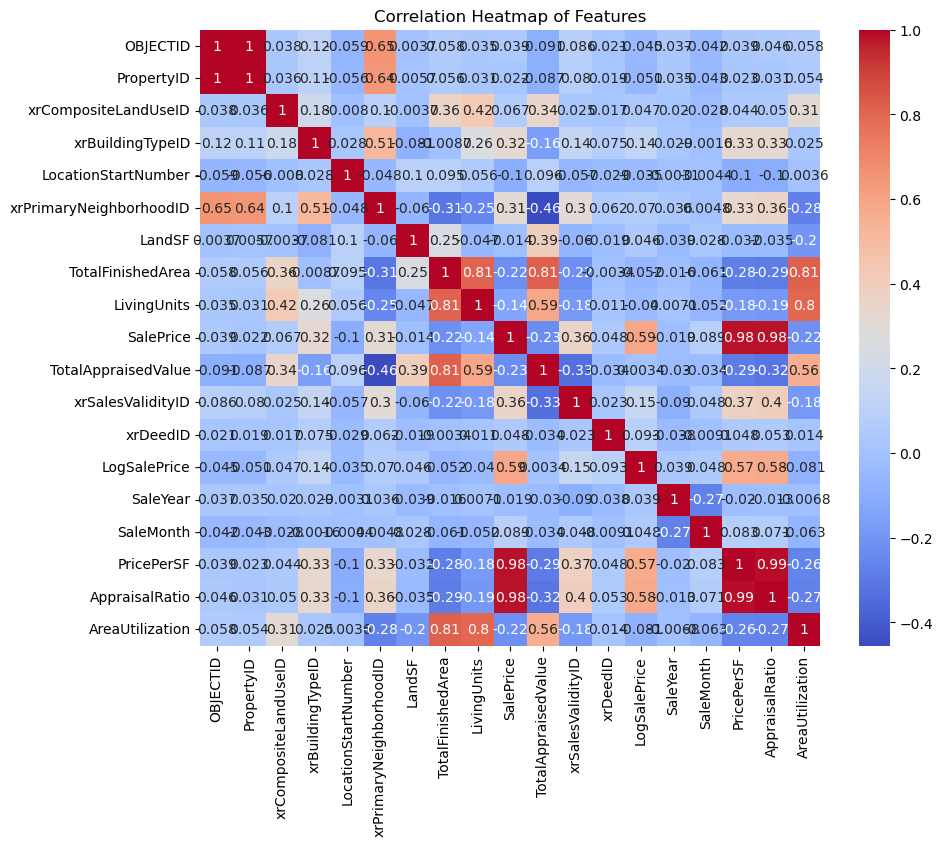

In [42]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
correlation_matrix = df_numeric.corr()

# Create heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

# Add title
plt.title("Correlation Heatmap of Features")

# Show plot
plt.show()

#The correlation heatmap shows that variables such as SalePrice, PricePerSF, and TotalFinishedArea have strong relationships with LogSalePrice, indicating their importance in predicting property prices.

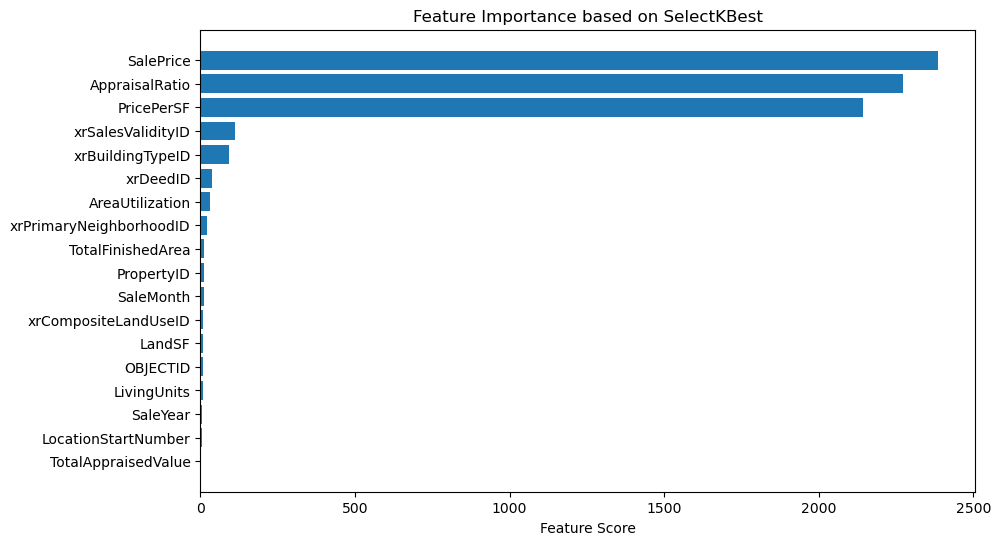

In [43]:
# Get feature scores from SelectKBest
scores = selector.scores_

# Convert to dataframe for easier plotting
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': scores
})

# Sort features by importance
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(feature_scores['Feature'], feature_scores['Score'])

plt.xlabel("Feature Score")
plt.title("Feature Importance based on SelectKBest")
plt.gca().invert_yaxis()

plt.show()

# Feature importance scores indicate the statistical relationship between each feature and the target variable LogSalePrice. Higher scores represent stronger influence on property prices.

In [ ]:
# Save the final processed dataset to a CSV file
final_df.to_csv("final_processed_dataset.csv", index=False)

print("Dataset saved successfully!")